In [1]:
# 1. Install Cython if not already present (usually is)
!pip install cython numpy

# 2. Clone the official repository
!git clone https://github.com/navefr/ExKMC.git

# 3. Move into the splitters directory and recompile the .pyx file
%cd ExKMC/ExKMC/splitters/
!cython cut_finder.pyx

# 4. Move back to the root and install
%cd ../..
!python setup.py install

Cloning into 'ExKMC'...
remote: Enumerating objects: 127, done.
remote: Counting objects: 100% (127/127), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 127 (delta 57), reused 102 (delta 38), pack-reused 0 (from 0)
Receiving objects: 100% (127/127), 1.58 MiB | 10.06 MiB/s, done.
Resolving deltas: 100% (57/57), done.
/content/ExKMC/ExKMC/splitters
/usr/local/lib/python3.12/dist-packages/Cython/Compiler/Main.py:381: FutureWarning: Cython directive 'language_level' not set, using '3str' for now (Py3). This has changed from earlier releases! File: /content/ExKMC/ExKMC/splitters/cut_finder.pyx
  tree = Parsing.p_module(s, pxd, full_module_name)
performance hint: cut_finder.pyx:86:5: Exception check on 'update_col_min_mistakes_cut' will always require the GIL to be acquired.
Possible solutions:
	1. Declare 'update_col_min_mistakes_cut' as 'noexcept' if you control the definition and you're sure you don't want the function to raise exceptions.
	2. Use an 'int' return typ

In [2]:
%cd /content

/content


In [3]:
import sys
import os

# This points to where your log said it installed the .egg
sys.path.append('/usr/local/lib/python3.12/dist-packages/ExKMC-0.0.3-py3.12-linux-x86_64.egg')

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import kagglehub
import graphviz
import re
from IPython.display import SVG, display
from ExKMC.Tree import Tree

In [5]:
# Download latest version
path = kagglehub.dataset_download("blurredmachine/are-your-employees-burning-out")
train_csv_path = os.path.join(path, 'train.csv')
test_csv_path = os.path.join(path, 'test.csv')

Using Colab cache for faster access to the 'are-your-employees-burning-out' dataset.


In [6]:
train = pd.read_csv(train_csv_path)

In [7]:
test = pd.read_csv(test_csv_path)

**Final train dataset including all row drops, imputations, and feature engineering from above.**

In [32]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Start from raw dataframe
df_clean = train.copy()

# Drop Employee ID
df_clean = df_clean.drop(columns=["Employee ID"])

# Drop rows where Burn Rate is null
df_clean = df_clean.dropna(subset=["Burn Rate"]).copy()

# Convert Date of Joining to days_since_joined using 2008-12-31 as reference
df_clean["Date of Joining"] = pd.to_datetime(df_clean["Date of Joining"])
reference_date = pd.Timestamp("2008-12-31")
df_clean["days_since_joined"] = (reference_date - df_clean["Date of Joining"]).dt.days
df_clean = df_clean.drop(columns=["Date of Joining"])

# Binary encoding
# gender: Male = 1, Female = 0
# company_type: Service = 1, Product = 0
# is_wfh: Yes = 1, No = 0
df_clean["gender"] = df_clean["Gender"].map({"Male": 1, "Female": 0})
df_clean["company_type"] = df_clean["Company Type"].map({"Service": 1, "Product": 0})
df_clean["is_wfh"] = df_clean["WFH Setup Available"].map({"Yes": 1, "No": 0})

df_clean = df_clean.drop(columns=["Gender", "Company Type", "WFH Setup Available"])

# Columns to impute
cols_to_impute = ["Mental Fatigue Score", "Resource Allocation"]

# -----------------------------
# Median-imputed + engineered + scaled dataset
# -----------------------------
df_median = df_clean.copy()

for col in cols_to_impute:
    df_median[col] = df_median[col].fillna(df_median[col].median())

# Feature engineering
df_median["Workload Fatigue Interaction"] = df_median["Resource Allocation"] * df_median["Mental Fatigue Score"]
df_median["Fatigue Ratio"] = df_median["Mental Fatigue Score"] / df_median["Resource Allocation"]
df_median["High Workload"] = np.where(
    df_median["Resource Allocation"] > df_median["Resource Allocation"].median(), 1, 0
)
df_median["High Fatigue"] = np.where(
    df_median["Mental Fatigue Score"] > df_median["Mental Fatigue Score"].median(), 1, 0
)
df_median["Stress Index"] = (
    0.7 * df_median["Mental Fatigue Score"] + 0.3 * df_median["Resource Allocation"]
)

# Continuous columns to scale
scale_cols = [
    "Designation",
    "Resource Allocation",
    "Mental Fatigue Score",
    "days_since_joined",
    "Workload Fatigue Interaction",
    "Fatigue Ratio",
    "Stress Index"
]

scaler_median = StandardScaler()
df_median[scale_cols] = scaler_median.fit_transform(df_median[scale_cols])

# -----------------------------
# Empirical probabilistic-imputed + engineered + scaled dataset
# -----------------------------
df_prob = df_clean.copy()
rng = np.random.default_rng(42)

for col in cols_to_impute:
    missing_mask = df_prob[col].isna()
    observed_values = df_prob.loc[~missing_mask, col].values
    df_prob.loc[missing_mask, col] = rng.choice(
        observed_values,
        size=missing_mask.sum(),
        replace=True
    )

# Feature engineering
df_prob["Workload Fatigue Interaction"] = df_prob["Resource Allocation"] * df_prob["Mental Fatigue Score"]
df_prob["Fatigue Ratio"] = df_prob["Mental Fatigue Score"] / df_prob["Resource Allocation"]
df_prob["High Workload"] = np.where(
    df_prob["Resource Allocation"] > df_prob["Resource Allocation"].median(), 1, 0
)
df_prob["High Fatigue"] = np.where(
    df_prob["Mental Fatigue Score"] > df_prob["Mental Fatigue Score"].median(), 1, 0
)
df_prob["Stress Index"] = (
    0.7 * df_prob["Mental Fatigue Score"] + 0.3 * df_prob["Resource Allocation"]
)

scaler_prob = StandardScaler()
df_prob[scale_cols] = scaler_prob.fit_transform(df_prob[scale_cols])

print("Median-imputed + engineered + scaled dataset preview:")
print(df_median.head())

print("\nProbabilistic-imputed + engineered + scaled dataset preview:")
print(df_prob.head())

Median-imputed + engineered + scaled dataset preview:
   Designation  Resource Allocation  Mental Fatigue Score  Burn Rate  \
0    -0.157448            -0.731293             -1.061201       0.16   
1    -1.038193            -1.233817             -0.406527       0.36   
2    -0.157448            -0.228769              0.029922       0.49   
3    -1.038193            -1.736341             -1.715875       0.20   
4     0.723298             1.278804              0.630040       0.52   

   days_since_joined  gender  company_type  is_wfh  \
0          -0.860105       0             1       0   
1          -1.438959       1             1       1   
2           1.075734       0             0       1   
3          -1.182745       1             1       1   
4          -0.214825       0             1       0   

   Workload Fatigue Interaction  Fatigue Ratio  High Workload  High Fatigue  \
0                     -0.905036      -0.284519              0             0   
1                     -0.98002

**Use df_prob as the main and df_median as the baseline**

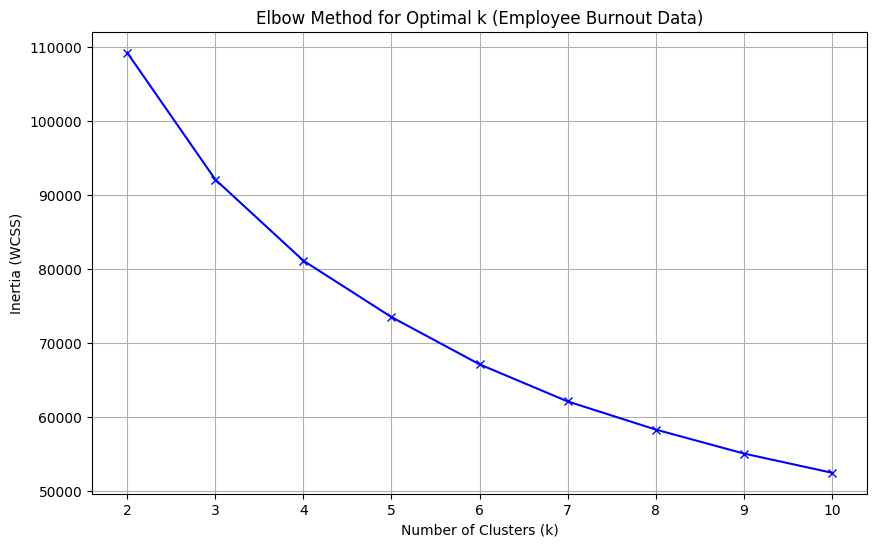

In [33]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Prepare features for clustering
# We exclude 'Burn Rate' from the clustering itself so we can use it to validate the clusters later
cluster_features = [col for col in df_prob.columns if col not in ['Burn Rate']]
X_elbow = df_prob[cluster_features]

# 2. Run Elbow Test
wcss = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_elbow)
    wcss.append(kmeans.inertia_)

# 3. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal k (Employee Burnout Data)')
plt.grid(True)
plt.show()


Visualizing Employee Burnout Personas (k=4, max_leaves=8):


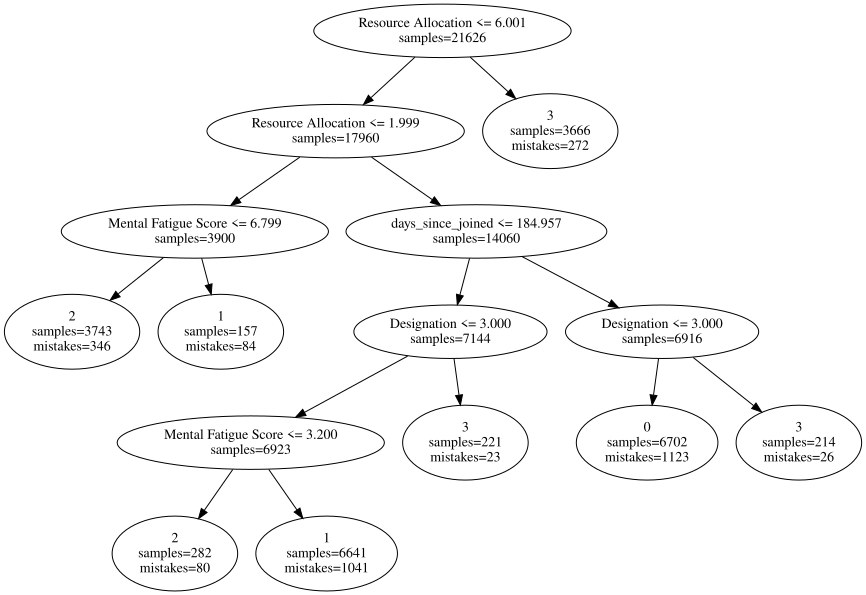


--- Employee Burnout Persona Report ---


,Avg_Burn_Rate,Avg_Fatigue_Score,Avg_Resources,Avg_Designation,Avg_Days_Joined,WFH_Percent,Percent_Male,Employee_Count
burnout_cluster,,,,,,,,
3.0,0.689734,7.550378,7.447940,3.675689,181.537430,32.7%,58.2%,4101
1.0,0.456362,5.976625,4.412768,2.135040,96.222860,55.6%,47.1%,6798
0.0,0.449430,5.802059,4.433602,2.121009,275.883169,55.9%,46.2%,6702
2.0,0.206718,3.350634,1.684224,0.823602,174.450186,69.9%,39.5%,4025


In [44]:
# 1. Configuration
k_optimal = 4

# Add the engineered interaction terms to the forbidden list
engineered_cols = [
    "Workload Fatigue Interaction",
    "Fatigue Ratio",
    "High Workload",
    "High Fatigue",
    "Stress Index"
]
forbidden_cols = ['Burn Rate', 'burnout_cluster', 'Employee ID'] + engineered_cols

all_features = [col for col in df_prob.columns if col not in forbidden_cols]

X_final = df_prob[all_features].values

# 2. Fit ExKMC
model_tree = Tree(k=k_optimal, max_leaves=8, random_state=42)
model_tree.fit(X_final)

# 3. Generate Labels
df_prob['burnout_cluster'] = model_tree.predict(X_final)

# 4. Explainable Plotting with Inverse Scaling
gv_file = 'burnout_tree.gv'
try:
    model_tree.plot('burnout_tree', feature_names=all_features, view=False)

    with open(gv_file, 'r') as f:
        dot_data = f.read()

    def inverse_transform_burnout(match):
        feature, threshold = match.group(1).strip(), float(match.group(2))
        # Ensure we only try to scale columns that were originally part of scale_cols
        if feature in scale_cols:
            idx = scale_cols.index(feature)
            original_val = (threshold * np.sqrt(scaler_prob.var_[idx])) + scaler_prob.mean_[idx]
            return f'{feature} <= {original_val:.3f}'
        return match.group(0)

    readable_dot_data = re.sub(r'([\w_ ]+) <= ([-+]?\d*\.\d+|\d+)', inverse_transform_burnout, dot_data)

    print(f"\nVisualizing Employee Burnout Personas (k={k_optimal}, max_leaves=8):")
    s = graphviz.Source(readable_dot_data, filename="burnout_tree_final", format="svg")
    display(SVG(s.render(cleanup=True)))

except Exception as e:
    print(f"Visualization failed: {e}")

# 5. Burnout Persona Summary
print("\n--- Employee Burnout Persona Report ---")

df_report = df_prob.copy()
# Only unscale columns that are still in our reporting set
for col in [c for c in scale_cols if c in df_report.columns]:
    idx = scale_cols.index(col)
    df_report[col] = (df_prob[col] * np.sqrt(scaler_prob.var_[idx])) + scaler_prob.mean_[idx]

summary = df_report.groupby('burnout_cluster').agg({
    'Burn Rate': 'mean',
    'Mental Fatigue Score': 'mean',
    'Resource Allocation': 'mean',
    'Designation': 'mean',
    'days_since_joined': 'mean',
    'is_wfh': 'mean',
    'gender': ['mean', 'count']
})

# 6. Clean up Column Names
summary.columns = [
    'Avg_Burn_Rate',
    'Avg_Fatigue_Score',
    'Avg_Resources',
    'Avg_Designation',
    'Avg_Days_Joined',
    'WFH_Percent',
    'Percent_Male',
    'Employee_Count'
]

# 7. Format for readability
summary['WFH_Percent'] = (summary['WFH_Percent'] * 100).round(1).astype(str) + '%'
summary['Percent_Male'] = (summary['Percent_Male'] * 100).round(1).astype(str) + '%'

display(summary.sort_values(by='Avg_Burn_Rate', ascending=False))

Cluster 3: The High-Load "At-Risk" Segment<br>
This cluster is found via three different paths, but they all share a common theme of high pressure.The Primary Group: Employees with Resource Allocation > 6.0. This is the tree's very first split, indicating that extreme workload is the #1 identifier for this persona.The "Tenured Under-Performer": Employees with moderate resources (between 2 and 6) but who have been with the company a long time (> 185 days) and have a high designation (> 3.0).Persona: These are your "Workhorses." They are likely the most senior people carrying the heaviest project loads.<br>
Cluster 2:  The Low-Resource "Quiet" Group<br>
The Path: Low Resource Allocation ($\le$ 1.9) AND Low Fatigue ($\le$ 6.8).Persona: These employees have manageable workloads and healthy mental fatigue scores. They represent the "Safe Zone" of your organization where burn rate is likely at its lowest.<br>
Cluster 1:The "Fatigued Newbies"<br>
The Path: Moderate resources (2 to 6) but very high Mental Fatigue (> 6.8). Another significant group shows up for those with low tenure ($\le$ 185 days) who have moderate fatigue (> 3.2).Persona: This is a "Warning" segment. Even if their actual resource count isn't the highest, their subjective fatigue is high. The tenure split suggests that newer employees might be struggling with the learning curve or lack of support, leading to fatigue even without "extreme" workloads.<br>
Cluster 0: The "Mid-Tier Managers"<br>
The Path: Moderate resources (2 to 6), long tenure (> 185 days), but a lower designation ($\le$ 3.0).Persona: These are your established, mid-level staff. They have survived the initial "newbie" phase and haven't yet been promoted into the high-stress, high-resource "Cluster 3" roles. They are the stable core of the workforce.

Key Takeaways from the 8-Leaf Expansion<br>
1. Resource Allocation is the King Split: The model immediately separates the "Extreme Workload" (Cluster 3) from everyone else.<br>

2. The "185-Day" Milestone: The tree reveals that tenure significantly changes how employees experience their workload. Employees who have been around for more than 6 months are processed through a different logic (Designation) than those who are newer.<br>

3. Redundancy for Accuracy: Notice how Cluster 1 and Cluster 3 appear in multiple leaves. This is ExKMC doing its job—it's using multiple "rectangles" to more accurately capture the shape of those burnout personas than a simple 4-leaf tree ever could.<br>